In [1]:
import logging

In [2]:
from pluot import render_to_image, get_logger

In [3]:
logger = get_logger()
logger.setLevel(logging.ERROR)

In [20]:
#await render_to_image(width=800, height=800, plot_id="test2", plot_type="Triangle", store_name="test")

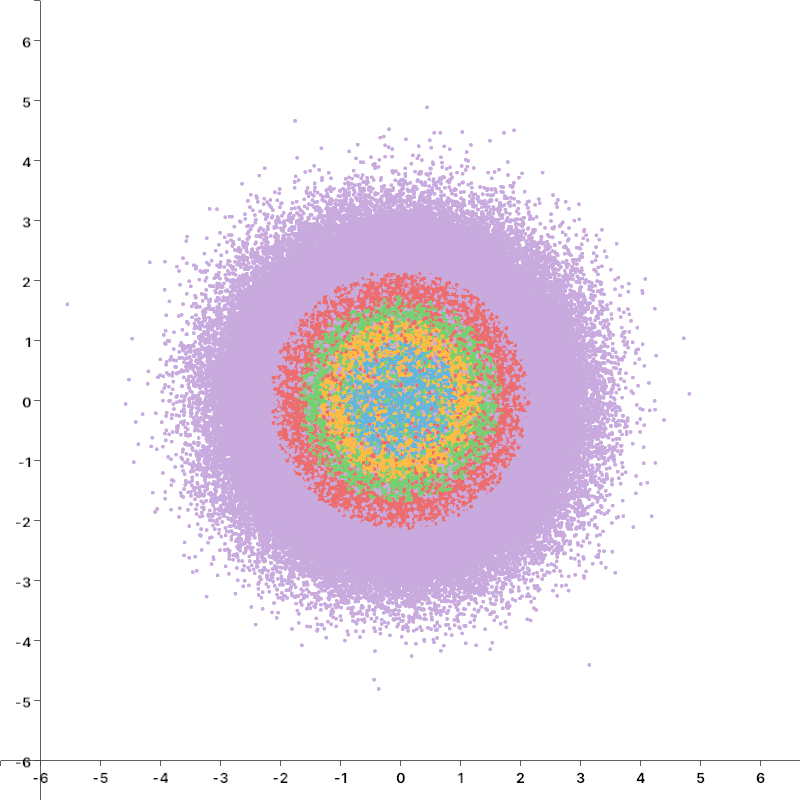

In [6]:
camera_view = [
    0.15, 0.0, 0.0, 0.0,
    0.0, 0.15, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0,
]

await render_to_image(
    camera_view=camera_view, width=800, height=800, plot_id="test", plot_type="Scatterplot", store_name="my_store",
    plot_params=dict(x_key="/n_1000000/x_coords", y_key="/n_1000000/y_coords", color_key="/n_1000000/class_labels", point_radius=4.0),
)

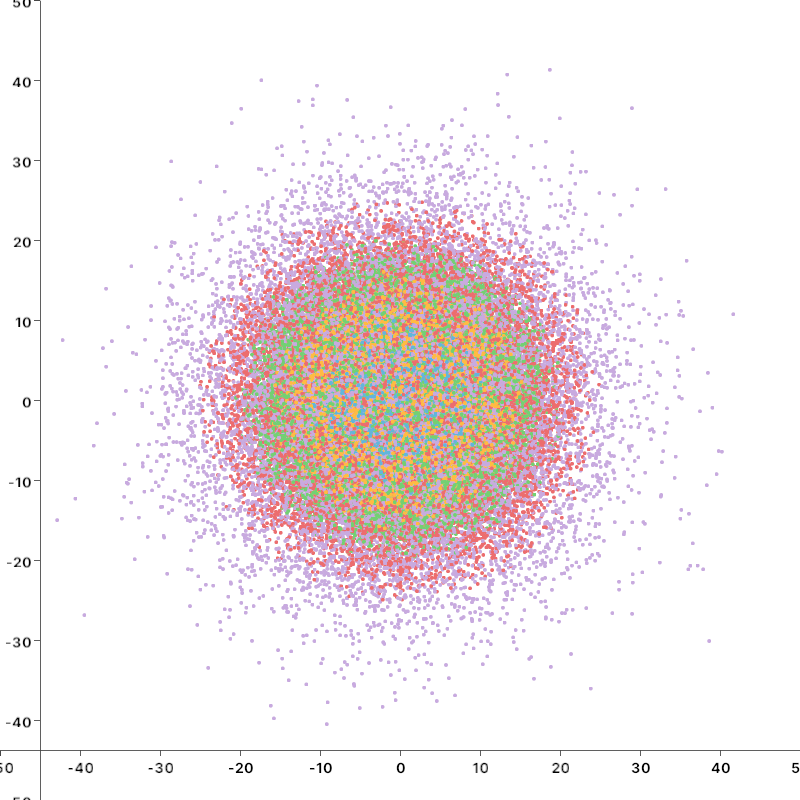

In [7]:
camera_view = [
    0.02, 0.0, 0.0, 0.0,
    0.0, 0.02, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0,
]

await render_to_image(
    camera_view=camera_view, width=800, height=800, plot_id="test", plot_type="Scatterplot3d", store_name="my_store",
    plot_params=dict(x_key="/n_1000000/x_coords", y_key="/n_1000000/y_coords", z_key="/n_1000000/z_coords", color_key="/n_1000000/class_labels", point_radius=4.0),
)

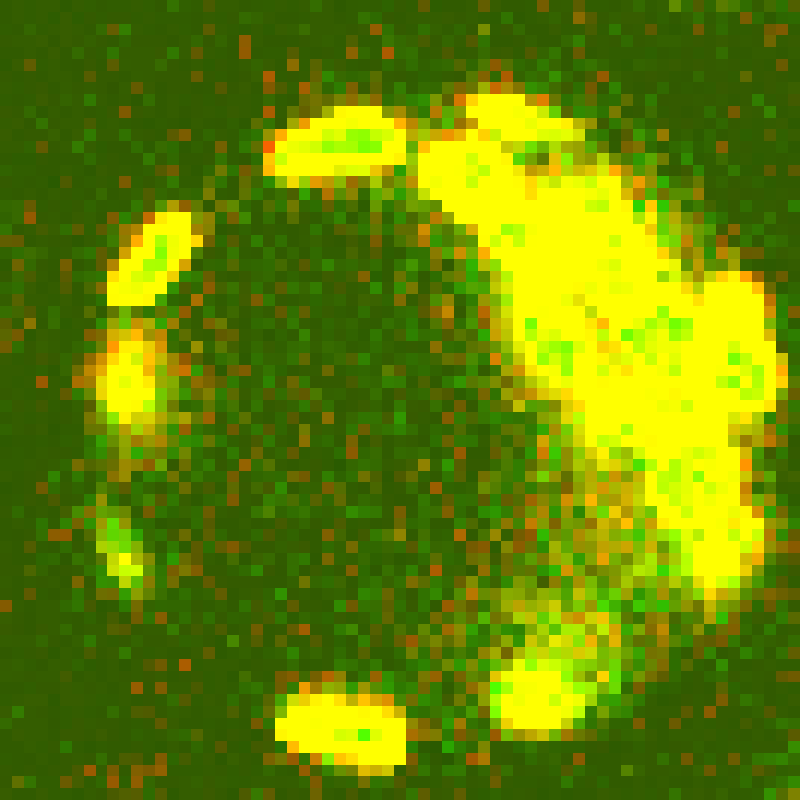

In [8]:
camera_view = [
    1.0, 0.0, 0.0, 0.0,
    0.0, 1.0, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0,
]

await render_to_image(
    camera_view=camera_view, width=800, height=800, plot_id="test", plot_type="Bioimage", store_name="ome_ngff",
    plot_params=dict(target_z=99, channel_indices=[0, 1], channel_windows=[[0.0, 1.0], [0.0, 1.0]], channel_colors=[[255, 0, 0], [0, 255, 0]]),
)

In [9]:
import zarr
import pluot.zarr
from os.path import join

#await pluot.zarr.zarr_get("my_store", "n_1000000/x_coords/zarr.json")

In [10]:
pluot.zarr.GLOBAL_STORES["mnist_store"] = zarr.storage.LocalStore(join("..", "data", "out", "mnist.zarr"))

In [11]:
import numpy as np

In [12]:
x_arr = np.array([-1, -1, 1, 1], dtype=float)
y_arr = np.array([-1, 1, -1, 1], dtype=float)
labels_arr = np.array([1, 2, 3, 4], dtype=int)

In [13]:
z = zarr.open(join("..", "data", "out", "screen_quad.zarr"))

no_compression = dict(filters=None, compressors=None, serializer="auto")

z.create_array(name=f"/x_coords", data=x_arr.astype(float), **no_compression, overwrite=True)
z.create_array(name=f"/y_coords", data=y_arr.astype(float), **no_compression, overwrite=True)
z.create_array(name=f"/class_labels", data=labels_arr.astype(int), **no_compression, overwrite=True)

<Array file://../data/out/screen_quad.zarr/class_labels shape=(4,) dtype=int64>

In [14]:
pluot.zarr.GLOBAL_STORES["screen_quad"] = zarr.storage.LocalStore(join("..", "data", "out", "screen_quad.zarr"))

In [15]:
#await pluot.zarr.zarr_get("mnist_store", "umap/x_coords/zarr.json")

In [16]:
camera_view = [
    0.25, 0.0, 0.0, 0.0,
    0.0, 0.25, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0,
]

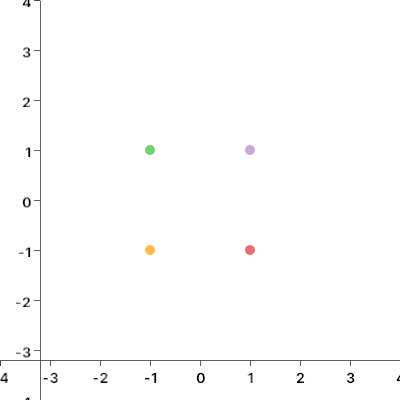

In [17]:
await render_to_image(
    camera_view=camera_view,
    width=400,
    height=400,
    plot_id="test",
    plot_type="Scatterplot",
    store_name="screen_quad",
    plot_params=dict(
        x_key="/x_coords",
        y_key="/y_coords",
        color_key="/class_labels",
        point_radius=10.0
    )
)

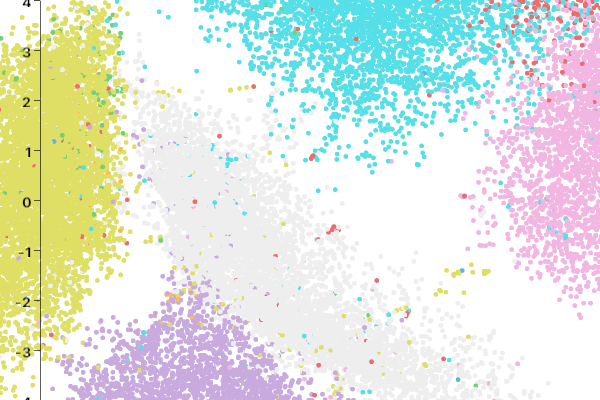

In [18]:
await render_to_image(
    camera_view=camera_view,
    width=600,
    height=400,
    plot_id="test",
    plot_type="Scatterplot",
    store_name="mnist_store",
    plot_params=dict(
        x_key="/densmap/x_coords",
        y_key="/densmap/y_coords",
        color_key="/densmap/class_labels",
    )
)

In [19]:
zoom = camera_view[0]
translate_x = camera_view[12]
translate_y = camera_view[13]
min_x = (-translate_x - 1)/zoom
max_x = (-translate_x + 1)/zoom
min_y = (-translate_y - 1)/zoom
max_y = (-translate_y + 1)/zoom
print(f"{zoom=}, {translate_x=}, {min_x=}, {max_x=}, {min_y=}, {max_y=}, {2.0/zoom}")

zoom=0.25, translate_x=0.0, min_x=-4.0, max_x=4.0, min_y=-4.0, max_y=4.0, 8.0
